In [1]:
import os
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Task 5 — Evidence-linked business recommendations

This notebook turns the Task 4 behavioral segments and measured 2025 behavior into six supportive proposals. It reports two populations separately: all **999 historical/model-assigned customers** and the **918 customers observed in December 2025**. The December group is only a recently observed analytical subset; neither population is known to be contactable or consented.

> **Non-punitive credit rule**  
> `financial_health_score` is a wellbeing indicator only. It must **never** be used to approve or deny credit, cut a credit limit, or block an account. Every proposal below is supportive and requires normal privacy, fairness and consent controls.

In [2]:
working_directory = Path.cwd().resolve()
project_root_override = os.environ.get("BI_PROJECT_ROOT")
if project_root_override:
    PROJECT_ROOT = Path(project_root_override).expanduser().resolve()
else:
    if working_directory.name != "code":
        raise RuntimeError(
            "Run this notebook with the working directory set to the repository's code/ folder, "
            "or set BI_PROJECT_ROOT explicitly."
        )
    PROJECT_ROOT = working_directory.parent

DATA_DIR = Path(os.environ.get("BI_DATA_DIR", PROJECT_ROOT / "data")).expanduser().resolve()
ARTIFACT_ROOT = Path(os.environ.get("BI_OUTPUT_DIR", PROJECT_ROOT)).expanduser().resolve()
MONTHLY_PATH = DATA_DIR / "consumer_financial_health_engagement_2025.csv"
TRANSACTION_PATH = DATA_DIR / "consumer_transactions_2025.csv"
FEATURE_PATH = ARTIFACT_ROOT / "code" / "outputs" / "segmentation_features.csv"
SEGMENT_PATH = ARTIFACT_ROOT / "code" / "outputs" / "customer_segments.csv"
TASK5_IMAGE_DIR = ARTIFACT_ROOT / "image" / "task5"

required_inputs = [MONTHLY_PATH, TRANSACTION_PATH, FEATURE_PATH, SEGMENT_PATH]
missing_inputs = [str(path) for path in required_inputs if not path.is_file()]
if missing_inputs:
    raise FileNotFoundError(
        "Task 5 requires the raw monthly and transaction files plus both executed Task 4 exports. "
        f"Missing: {missing_inputs}. Run Task 4 first; no substitute data will be created."
    )

try:
    TASK5_IMAGE_DIR.mkdir(parents=True, exist_ok=True)
    write_probe = TASK5_IMAGE_DIR / ".task5_write_probe"
    write_probe.write_text("writable", encoding="utf-8")
    write_probe.unlink()
except OSError as error:
    raise OSError(f"Task 5 output directory is not writable: {TASK5_IMAGE_DIR}") from error

print(f"Data directory: {DATA_DIR}")
print(f"Artifact root: {ARTIFACT_ROOT}")

Data directory: /home/pearspringmind/Studying/BI-UEL/data
Artifact root: /home/pearspringmind/Studying/BI-UEL


## 1. Load and validate the monthly and Task 4 data

The Task 4 feature and assignment files must each contain exactly one row for every source customer. The checks below reject missing, duplicate or mismatched IDs rather than filling or fabricating records.

In [3]:
monthly_columns = [
    "consumer_id", "analysis_month", "transaction_count", "total_spend_vnd",
    "essential_spend_ratio", "discretionary_spend_ratio",
    "spend_to_income_ratio", "credit_utilization_ratio",
    "financial_health_score", "engagement_score",
]
monthly_data = pd.read_csv(MONTHLY_PATH, usecols=monthly_columns, parse_dates=["analysis_month"])
segmentation_features = pd.read_csv(FEATURE_PATH)
customer_segments = pd.read_csv(SEGMENT_PATH)

required_feature_columns = {
    "consumer_id", "median_spend_to_income_ratio",
    "median_credit_utilization_ratio", "median_essential_spend_ratio",
    "median_online_spend_ratio", "log1p_mean_monthly_transaction_count",
    "n_observed_months", "latest_observed_month",
    "months_health_under_40", "stress_month_share",
    "mean_financial_health_score", "latest_financial_health_score",
    "mean_engagement_score", "latest_engagement_score",
}
required_segment_columns = {"consumer_id", "cluster", "cluster_label"}
missing_feature_columns = sorted(required_feature_columns - set(segmentation_features.columns))
missing_segment_columns = sorted(required_segment_columns - set(customer_segments.columns))
if missing_feature_columns or missing_segment_columns:
    raise ValueError(
        "Task 4 export schema is incomplete. "
        f"Missing feature columns: {missing_feature_columns}; "
        f"missing assignment columns: {missing_segment_columns}."
    )

numeric_monthly_columns = [column for column in monthly_columns if column not in {"consumer_id", "analysis_month"}]
monthly_data[numeric_monthly_columns] = monthly_data[numeric_monthly_columns].apply(pd.to_numeric, errors="raise")
if monthly_data[["consumer_id", "analysis_month"] + numeric_monthly_columns].isna().any().any():
    raise ValueError("Required monthly fields contain missing values.")
if not np.isfinite(monthly_data[numeric_monthly_columns].to_numpy(dtype=float)).all():
    raise ValueError("Required monthly numeric fields contain non-finite values.")
if monthly_data.duplicated(["consumer_id", "analysis_month"]).any():
    raise ValueError("The monthly source contains duplicate consumer-month keys.")
if not monthly_data["analysis_month"].dt.year.eq(2025).all():
    raise ValueError("The monthly source must contain only calendar year 2025.")
if not monthly_data["analysis_month"].dt.is_month_start.all():
    raise ValueError("Monthly analysis_month values must be normalized to the first day of each month.")
DECEMBER_ANALYSIS_MONTH = pd.Timestamp("2025-12-01")

if (monthly_data["transaction_count"].le(0) | monthly_data["transaction_count"].ne(
    monthly_data["transaction_count"].round()
)).any():
    raise ValueError("Every observed monthly transaction_count must be a positive integer.")
monthly_data["transaction_count"] = monthly_data["transaction_count"].astype("int64")
monthly_transaction_counts = monthly_data.assign(
    transaction_month=monthly_data["analysis_month"].dt.month.astype("int8")
).set_index(["consumer_id", "transaction_month"])["transaction_count"]
if monthly_transaction_counts.index.has_duplicates:
    raise ValueError("The monthly source must contain exactly one row per consumer_id and transaction month.")
monthly_transaction_counts = monthly_transaction_counts.rename("monthly_transaction_count").sort_index()

In [4]:
for frame_name, frame in {
    "segmentation_features": segmentation_features,
    "customer_segments": customer_segments,
}.items():
    if frame["consumer_id"].isna().any() or not frame["consumer_id"].is_unique:
        raise ValueError(f"{frame_name} must have a unique, non-missing consumer_id.")

monthly_customer_ids = set(monthly_data["consumer_id"])
feature_customer_ids = set(segmentation_features["consumer_id"])
segment_customer_ids = set(customer_segments["consumer_id"])
if len(monthly_customer_ids) != 999:
    raise ValueError(f"Expected 999 unique source customers, found {len(monthly_customer_ids)}.")
if not (feature_customer_ids == segment_customer_ids == monthly_customer_ids):
    raise ValueError(
        "Task 4 feature IDs, assignment IDs and monthly-source IDs must match exactly. "
        f"Feature-only: {sorted(feature_customer_ids - monthly_customer_ids)[:5]}; "
        f"assignment-only: {sorted(segment_customer_ids - monthly_customer_ids)[:5]}; "
        f"source IDs missing from features: {sorted(monthly_customer_ids - feature_customer_ids)[:5]}."
    )

model_customers = segmentation_features.merge(
    customer_segments[list(required_segment_columns)], on="consumer_id", how="inner", validate="one_to_one"
)
if len(model_customers) != 999 or model_customers[["cluster", "cluster_label"]].isna().any().any():
    raise ValueError("The exact Task 4 join must assign a non-missing cluster to all 999 customers.")

monthly_checks = monthly_data.groupby("consumer_id", as_index=False).agg(
    source_observed_months=("analysis_month", "size"),
    source_latest_month=("analysis_month", "max"),
    source_stressed_months=("financial_health_score", lambda values: int((values < 40).sum())),
)
export_checks = model_customers[[
    "consumer_id", "n_observed_months", "latest_observed_month", "months_health_under_40"
]].merge(monthly_checks, on="consumer_id", validate="one_to_one")
export_checks["latest_observed_month"] = pd.to_datetime(export_checks["latest_observed_month"], errors="raise")
coverage_mismatch = (
    export_checks["n_observed_months"].ne(export_checks["source_observed_months"])
    | export_checks["latest_observed_month"].ne(export_checks["source_latest_month"])
    | export_checks["months_health_under_40"].ne(export_checks["source_stressed_months"])
)
if coverage_mismatch.any():
    raise ValueError(
        "Task 4 history diagnostics do not reconcile to the raw monthly source for IDs: "
        f"{export_checks.loc[coverage_mismatch, 'consumer_id'].head().tolist()}"
    )

december_customer_ids = set(
    monthly_data.loc[monthly_data["analysis_month"].eq(DECEMBER_ANALYSIS_MONTH), "consumer_id"]
)
if len(december_customer_ids) != 918 or not december_customer_ids.issubset(monthly_customer_ids):
    raise ValueError(
        f"Expected 918 December-observed customers as a subset of the 999; found {len(december_customer_ids)}."
    )

print("Validated exact 1:1 Task 4 join: 999 of 999 customers.")
print("Reach populations: 999 historical/model-assigned; 918 observed in December 2025.")

Validated exact 1:1 Task 4 join: 999 of 999 customers.
Reach populations: 999 historical/model-assigned; 918 observed in December 2025.


## 2. Stream customer-level non-POS adoption

Only `consumer_id`, `transaction_month` and `transaction_channel` are read in bounded chunks. The scan counts all input rows and reconciles every customer-month count exactly to the monthly source before computing channel shares. It retains compact annual, December, Jan–Aug training-window and Sep–Dec validation-window channel counts. A digital/non-POS transaction is any listed channel other than POS, so **QR Payment is digital even though its `online_transaction_flag` can be 0**.

In [5]:
transaction_chunk_size = 100_000
expected_channels = {"POS", "E-commerce", "Mobile App", "QR Payment", "Recurring Payment"}
customer_index = pd.Index(sorted(monthly_customer_ids), name="consumer_id")
year_transaction_count = pd.Series(0, index=customer_index, dtype="int64")
year_non_pos_count = pd.Series(0, index=customer_index, dtype="int64")
december_transaction_count = pd.Series(0, index=customer_index, dtype="int64")
december_non_pos_count = pd.Series(0, index=customer_index, dtype="int64")
training_non_pos_count = pd.Series(0, index=customer_index, dtype="int64")
validation_non_pos_count = pd.Series(0, index=customer_index, dtype="int64")
transaction_month_presence = pd.DataFrame(False, index=customer_index, columns=range(1, 13))
scanned_transaction_rows = 0
transaction_month_counts = pd.Series(
    dtype="int64",
    index=pd.MultiIndex.from_arrays([[], []], names=["consumer_id", "transaction_month"]),
    name="scanned_transaction_count",
)

for transaction_chunk in pd.read_csv(
    TRANSACTION_PATH,
    usecols=["consumer_id", "transaction_month", "transaction_channel"],
    chunksize=transaction_chunk_size,
):
    if transaction_chunk[["consumer_id", "transaction_month", "transaction_channel"]].isna().any().any():
        raise ValueError("Required transaction channel fields contain missing values.")
    transaction_month_values = pd.to_numeric(
        transaction_chunk["transaction_month"], errors="raise"
    )
    valid_transaction_months = (
        np.isfinite(transaction_month_values.to_numpy(dtype=float)).all()
        and transaction_month_values.between(1, 12).all()
        and transaction_month_values.eq(transaction_month_values.round()).all()
    )
    if not valid_transaction_months:
        raise ValueError("transaction_month must be a finite integer from 1 through 12.")
    transaction_chunk["transaction_month"] = transaction_month_values.astype("int8")
    unexpected_customer_ids = set(transaction_chunk["consumer_id"]) - monthly_customer_ids
    if unexpected_customer_ids:
        raise ValueError(f"Transactions contain unknown customer IDs: {sorted(unexpected_customer_ids)[:5]}")
    unexpected_channels = set(transaction_chunk["transaction_channel"]) - expected_channels
    if unexpected_channels:
        raise ValueError(f"Unexpected transaction channels: {sorted(unexpected_channels)}")

    scanned_transaction_rows += len(transaction_chunk)
    chunk_month_counts = transaction_chunk.groupby(
        ["consumer_id", "transaction_month"], sort=False
    ).size().rename("scanned_transaction_count")
    transaction_month_counts = transaction_month_counts.add(
        chunk_month_counts, fill_value=0
    ).astype("int64")

    chunk_year_counts = transaction_chunk.groupby("consumer_id").size()
    year_transaction_count = year_transaction_count.add(chunk_year_counts, fill_value=0)
    non_pos_rows = transaction_chunk["transaction_channel"].ne("POS")
    chunk_non_pos_counts = transaction_chunk.loc[non_pos_rows].groupby("consumer_id").size()
    year_non_pos_count = year_non_pos_count.add(chunk_non_pos_counts, fill_value=0)

    december_rows = transaction_chunk["transaction_month"].eq(12)
    chunk_december_counts = transaction_chunk.loc[december_rows].groupby("consumer_id").size()
    chunk_december_non_pos = transaction_chunk.loc[december_rows & non_pos_rows].groupby("consumer_id").size()
    december_transaction_count = december_transaction_count.add(chunk_december_counts, fill_value=0)
    december_non_pos_count = december_non_pos_count.add(chunk_december_non_pos, fill_value=0)
    training_rows = transaction_chunk["transaction_month"].le(8)
    validation_rows = transaction_chunk["transaction_month"].ge(9)
    chunk_training_non_pos = transaction_chunk.loc[training_rows & non_pos_rows].groupby("consumer_id").size()
    chunk_validation_non_pos = transaction_chunk.loc[validation_rows & non_pos_rows].groupby("consumer_id").size()
    training_non_pos_count = training_non_pos_count.add(chunk_training_non_pos, fill_value=0)
    validation_non_pos_count = validation_non_pos_count.add(chunk_validation_non_pos, fill_value=0)

    chunk_month_presence = pd.crosstab(
        transaction_chunk["consumer_id"], transaction_chunk["transaction_month"]
    ).gt(0)
    transaction_month_presence.loc[chunk_month_presence.index, chunk_month_presence.columns] |= chunk_month_presence

year_transaction_count = year_transaction_count.astype("int64")
year_non_pos_count = year_non_pos_count.astype("int64")
december_transaction_count = december_transaction_count.astype("int64")
december_non_pos_count = december_non_pos_count.astype("int64")
training_non_pos_count = training_non_pos_count.astype("int64")
validation_non_pos_count = validation_non_pos_count.astype("int64")

expected_transaction_rows = 1_852_394
if scanned_transaction_rows != expected_transaction_rows:
    raise ValueError(
        "Transaction row-count validation failed: "
        f"expected {expected_transaction_rows:,} rows, scanned {scanned_transaction_rows:,}."
    )
if int(transaction_month_counts.sum()) != scanned_transaction_rows:
    raise RuntimeError(
        "Bounded transaction scan failed internally: customer-month partial counts "
        "do not sum to the scanned row total."
    )

transaction_only_keys = transaction_month_counts.index.difference(
    monthly_transaction_counts.index, sort=False
)
monthly_only_keys = monthly_transaction_counts.index.difference(
    transaction_month_counts.index, sort=False
)
if len(transaction_only_keys) or len(monthly_only_keys):
    raise ValueError(
        "Transaction customer-month keys do not reconcile 1:1 with the monthly source. "
        f"Transaction-only keys: {len(transaction_only_keys)} "
        f"(examples: {list(transaction_only_keys[:5])}); "
        f"monthly-only keys: {len(monthly_only_keys)} "
        f"(examples: {list(monthly_only_keys[:5])})."
    )

transaction_count_reconciliation = pd.concat(
    [transaction_month_counts, monthly_transaction_counts], axis=1, join="inner"
)
mismatched_transaction_counts = transaction_count_reconciliation[
    transaction_count_reconciliation["scanned_transaction_count"].ne(
        transaction_count_reconciliation["monthly_transaction_count"]
    )
]
if not mismatched_transaction_counts.empty:
    mismatch_examples = (
        mismatched_transaction_counts.reset_index().head(5).to_dict(orient="records")
    )
    raise ValueError(
        "Transaction counts do not reconcile to monthly transaction_count values for "
        f"{len(mismatched_transaction_counts)} customer-month keys. "
        f"Examples: {mismatch_examples}"
    )
if set(year_transaction_count[year_transaction_count.gt(0)].index) != monthly_customer_ids:
    raise ValueError("Transaction and monthly customer populations do not match exactly.")
if set(december_transaction_count[december_transaction_count.gt(0)].index) != december_customer_ids:
    raise ValueError("December transaction customers do not match the December monthly population.")

print(
    "Validated transaction source: "
    f"{scanned_transaction_rows:,} rows and {len(transaction_count_reconciliation):,} "
    "customer-month counts reconcile exactly to the monthly table."
)

channel_adoption = pd.DataFrame({
    "year_transaction_count": year_transaction_count,
    "year_non_pos_count": year_non_pos_count,
    "december_transaction_count": december_transaction_count,
    "december_non_pos_count": december_non_pos_count,
    "n_transaction_months_year": transaction_month_presence.sum(axis=1).astype("int8"),
}).reset_index()
channel_adoption["non_pos_transaction_share_year"] = (
    channel_adoption["year_non_pos_count"] / channel_adoption["year_transaction_count"]
)
channel_adoption["used_non_pos_year"] = channel_adoption["year_non_pos_count"].gt(0)
channel_adoption["non_pos_transaction_share_december"] = np.where(
    channel_adoption["december_transaction_count"].gt(0),
    channel_adoption["december_non_pos_count"] / channel_adoption["december_transaction_count"],
    np.nan,
)
channel_adoption["used_non_pos_december"] = channel_adoption["december_non_pos_count"].gt(0)

adoption_summary = pd.DataFrame({
    "Population": ["Historical/model-assigned", "Observed in December 2025"],
    "Denominator": [999, 918],
    "Customers using at least one non-POS channel": [
        int(channel_adoption["used_non_pos_year"].sum()),
        int(channel_adoption.loc[channel_adoption["consumer_id"].isin(december_customer_ids), "used_non_pos_december"].sum()),
    ],
})
adoption_summary["Adoption (%)"] = (
    100 * adoption_summary["Customers using at least one non-POS channel"] / adoption_summary["Denominator"]
).round(1)
display(adoption_summary)

Validated transaction source: 1,852,394 rows and 10,992 customer-month counts reconcile exactly to the monthly table.


,Population,Denominator,Customers using at least one non-POS channel,Adoption (%)
0,Historical/model-assigned,999,999,100.0
1,Observed in December 2025,918,917,99.9


## 3. Build separate historical and December evidence views

Historical features summarize each customer's available 2025 months without filling absent months. December spend change is computed only against that customer's available pre-December median; customers with no earlier month have an unknown trend.

In [6]:
customer_history = monthly_data.groupby("consumer_id", as_index=False).agg(
    n_observed_months=("analysis_month", "size"),
    median_spend_to_income_ratio=("spend_to_income_ratio", "median"),
    median_credit_utilization_ratio=("credit_utilization_ratio", "median"),
    median_essential_spend_ratio=("essential_spend_ratio", "median"),
    median_discretionary_spend_ratio=("discretionary_spend_ratio", "median"),
    median_total_spend_vnd=("total_spend_vnd", "median"),
    maximum_total_spend_vnd=("total_spend_vnd", "max"),
    months_health_under_40=("financial_health_score", lambda values: int((values < 40).sum())),
    stress_month_share=("financial_health_score", lambda values: float((values < 40).mean())),
    mean_financial_health_score=("financial_health_score", "mean"),
    mean_engagement_score=("engagement_score", "mean"),
)
customer_history["peak_spend_vs_personal_median"] = (
    customer_history["maximum_total_spend_vnd"] / customer_history["median_total_spend_vnd"]
)

pre_december_history = monthly_data.loc[
    monthly_data["analysis_month"].lt(DECEMBER_ANALYSIS_MONTH)
].groupby("consumer_id", as_index=False).agg(
    prior_month_count=("analysis_month", "size"),
    prior_median_total_spend_vnd=("total_spend_vnd", "median"),
)
december_snapshot = monthly_data.loc[
    monthly_data["analysis_month"].eq(DECEMBER_ANALYSIS_MONTH)
].merge(
    pre_december_history, on="consumer_id", how="left", validate="one_to_one"
)
december_snapshot["prior_month_count"] = december_snapshot["prior_month_count"].fillna(0).astype("int16")
december_snapshot["december_spend_vs_prior_median"] = np.where(
    december_snapshot["prior_month_count"].gt(0),
    december_snapshot["total_spend_vnd"] / december_snapshot["prior_median_total_spend_vnd"],
    np.nan,
)

model_identity = model_customers[["consumer_id", "cluster", "cluster_label"]]
historical_population = model_identity.merge(
    customer_history, on="consumer_id", validate="one_to_one"
).merge(channel_adoption, on="consumer_id", validate="one_to_one").set_index("consumer_id")
december_population = model_identity.merge(
    december_snapshot, on="consumer_id", validate="one_to_one"
).merge(channel_adoption, on="consumer_id", validate="one_to_one").set_index("consumer_id")
if len(historical_population) != 999 or len(december_population) != 918:
    raise ValueError("The analytical reach views must contain exactly 999 and 918 unique customers.")
if december_population.index.duplicated().any() or historical_population.index.duplicated().any():
    raise ValueError("Reach populations must contain unique customer IDs.")

In [7]:
cluster_profiles = historical_population.groupby(["cluster", "cluster_label"], as_index=False).agg(
    customers=("cluster", "size"),
    median_observed_months=("n_observed_months", "median"),
    median_spend_to_income=("median_spend_to_income_ratio", "median"),
    median_essential_share=("median_essential_spend_ratio", "median"),
    median_discretionary_share=("median_discretionary_spend_ratio", "median"),
    median_credit_utilization=("median_credit_utilization_ratio", "median"),
    median_non_pos_share=("non_pos_transaction_share_year", "median"),
    customers_with_stress=("months_health_under_40", lambda values: int((values > 0).sum())),
)
cluster_profiles["population_share_pct"] = (100 * cluster_profiles["customers"] / 999).round(1)
cluster_profiles["stress_customer_pct"] = (
    100 * cluster_profiles["customers_with_stress"] / cluster_profiles["customers"]
).round(1)
profile_display_columns = [
    "cluster", "cluster_label", "customers", "population_share_pct",
    "median_observed_months", "median_spend_to_income",
    "median_essential_share", "median_discretionary_share",
    "median_credit_utilization", "median_non_pos_share", "stress_customer_pct",
]
display(cluster_profiles[profile_display_columns].round(3))

,cluster,cluster_label,customers,population_share_pct,median_observed_months,median_spend_to_income,median_essential_share,median_discretionary_share,median_credit_utilization,median_non_pos_share,stress_customer_pct
0,0,Lower-frequency activity — Segment 1,545,54.6,12.0,0.617,0.526,0.474,0.161,0.399,8.8
1,1,Higher online-spend share — Segment 2,454,45.4,12.0,0.669,0.434,0.566,0.182,0.429,4.8


The cluster table is descriptive context, not an eligibility rule. Each proposal below combines a measured need with the cluster in which that need is most prevalent; customers in other clusters remain eligible when they meet the same behavioral predicate.

In [8]:
distribution_review = historical_population[[
    "median_spend_to_income_ratio", "peak_spend_vs_personal_median",
    "median_discretionary_spend_ratio", "median_essential_spend_ratio",
    "median_credit_utilization_ratio", "non_pos_transaction_share_year",
]].quantile([0.25, 0.50, 0.75]).rename_axis("quantile")
display(distribution_review.round(3))

high_spend_income_threshold = float(monthly_data["spend_to_income_ratio"].quantile(0.75))
monthly_high_spend_income = monthly_data.assign(
    high_spend_income=monthly_data["spend_to_income_ratio"].ge(high_spend_income_threshold)
).groupby("consumer_id")["high_spend_income"].mean()
historical_population["persistent_high_spend_income_share"] = monthly_high_spend_income

peak_spend_threshold = float(
    historical_population.loc[historical_population["n_observed_months"].ge(3), "peak_spend_vs_personal_median"].quantile(0.75)
)
discretionary_threshold = float(historical_population["median_discretionary_spend_ratio"].quantile(0.75))
essential_threshold = float(historical_population["median_essential_spend_ratio"].quantile(0.75))
low_non_pos_threshold = float(historical_population["non_pos_transaction_share_year"].quantile(0.25))
december_spend_income_threshold = float(december_population["spend_to_income_ratio"].quantile(0.75))
december_growth_threshold = float(
    december_population.loc[december_population["prior_month_count"].gt(0), "december_spend_vs_prior_median"].quantile(0.75)
)
december_growth_median = float(
    december_population.loc[december_population["prior_month_count"].gt(0), "december_spend_vs_prior_median"].median()
)
december_discretionary_threshold = float(december_population["discretionary_spend_ratio"].quantile(0.75))
december_essential_threshold = float(december_population["essential_spend_ratio"].quantile(0.75))
december_low_non_pos_threshold = float(
    december_population["non_pos_transaction_share_december"].quantile(0.25)
)

threshold_table = pd.DataFrame({
    "Threshold": [
        "Monthly spend-to-income upper quartile", "Historical peak/personal-median upper quartile",
        "Historical discretionary-share upper quartile", "Historical essential-share upper quartile",
        "Historical non-POS-share lower quartile", "December spend-to-income upper quartile",
        "December spend-growth upper quartile (prior history required)",
        "December discretionary-share upper quartile", "December essential-share upper quartile",
        "December non-POS-share lower quartile",
    ],
    "Computed value": [
        high_spend_income_threshold, peak_spend_threshold, discretionary_threshold, essential_threshold,
        low_non_pos_threshold, december_spend_income_threshold, december_growth_threshold,
        december_discretionary_threshold, december_essential_threshold, december_low_non_pos_threshold,
    ],
})
display(threshold_table.round(3))

,median_spend_to_income_ratio,peak_spend_vs_personal_median,median_discretionary_spend_ratio,median_essential_spend_ratio,median_credit_utilization_ratio,non_pos_transaction_share_year
quantile,,,,,,
0.25,0.541,1.735,0.467,0.436,0.136,0.393
0.50,0.639,1.961,0.507,0.493,0.168,0.409
0.75,0.725,2.262,0.564,0.533,0.206,0.429


,Threshold,Computed value
0,Monthly spend-to-income upper quartile,0.812
1,Historical peak/personal-median upper quartile,2.312
2,Historical discretionary-share upper quartile,0.564
3,Historical essential-share upper quartile,0.533
4,Historical non-POS-share lower quartile,0.393
5,December spend-to-income upper quartile,1.463
6,December spend-growth upper quartile (prior hi...,2.203
7,December discretionary-share upper quartile,0.581
8,December essential-share upper quartile,0.540
9,December non-POS-share lower quartile,0.382


## 4. Define six measured, non-punitive target predicates

Quartiles are calculated after reviewing the distributions and segment profiles above. They are prioritization thresholds, not clinical, risk or product-eligibility cutoffs. Historical persistence requires at least three observed months where a repeated pattern is claimed.

In [9]:
historical_targets = {
    "Budgeting tools": historical_population["n_observed_months"].ge(3)
        & historical_population["persistent_high_spend_income_share"].ge(0.50),
    "Spend alerts": historical_population["n_observed_months"].ge(3)
        & historical_population["peak_spend_vs_personal_median"].ge(peak_spend_threshold),
    "Financial-planning reminders": historical_population["months_health_under_40"].gt(0),
    "Financial education": historical_population["median_discretionary_spend_ratio"].ge(discretionary_threshold),
    "Digital nudges": historical_population["non_pos_transaction_share_year"].le(low_non_pos_threshold),
    "Suitable product suggestions": historical_population["n_observed_months"].ge(3)
        & historical_population["median_essential_spend_ratio"].ge(essential_threshold),
}
december_targets = {
    "Budgeting tools": december_population["spend_to_income_ratio"].ge(december_spend_income_threshold),
    "Spend alerts": december_population["prior_month_count"].gt(0)
        & december_population["december_spend_vs_prior_median"].ge(december_growth_threshold),
    "Financial-planning reminders": december_population["financial_health_score"].lt(40)
        | (
            december_population["prior_month_count"].gt(0)
            & december_population["spend_to_income_ratio"].ge(december_spend_income_threshold)
            & december_population["december_spend_vs_prior_median"].ge(december_growth_median)
        ),
    "Financial education": december_population["discretionary_spend_ratio"].ge(december_discretionary_threshold),
    "Digital nudges": december_population["non_pos_transaction_share_december"].le(december_low_non_pos_threshold),
    "Suitable product suggestions": december_population["essential_spend_ratio"].ge(december_essential_threshold),
}

for action_name in historical_targets:
    historical_targets[action_name] = historical_targets[action_name].fillna(False).astype(bool)
    december_targets[action_name] = december_targets[action_name].fillna(False).astype(bool)
    if int(historical_targets[action_name].sum()) == 0 or int(december_targets[action_name].sum()) == 0:
        raise ValueError(
            f"The measured predicate for {action_name} produced an empty population. "
            "Review the displayed distribution and redesign the supportive predicate rather than reporting fictitious reach."
        )
    if not set(historical_targets[action_name].index[historical_targets[action_name]]).issubset(monthly_customer_ids):
        raise AssertionError(f"{action_name} historical targets fall outside the declared population.")
    if not set(december_targets[action_name].index[december_targets[action_name]]).issubset(december_customer_ids):
        raise AssertionError(f"{action_name} December targets fall outside the declared population.")

In [10]:
action_specs = {
    "Budgeting tools": {
        "driver": "persistent_high_spend_income_share",
        "historical_predicate": f"At least 3 observed months and spend/income >= {high_spend_income_threshold:.3f} in at least half of them",
        "december_predicate": f"December spend/income >= its observed-customer upper quartile ({december_spend_income_threshold:.3f})",
        "action": "Offer an opt-in budget planner with category limits and cash-flow summaries; frame it as control and visibility, not restriction.",
        "future_kpi": "Randomized pilot: budget set-up rate and 3-month within-person spend/income change versus holdout.",
        "caveat": "Historical persistence requires 3+ months; a December-only signal is a snapshot and cannot establish a chronic pattern.",
    },
    "Spend alerts": {
        "driver": "peak_spend_vs_personal_median",
        "historical_predicate": f"At least 3 observed months and peak/monthly-personal-median spend >= {peak_spend_threshold:.3f}",
        "december_predicate": f"December/prior-personal-median spend >= {december_growth_threshold:.3f}; at least one prior month required",
        "action": "Let customers opt into real-time, user-set spend alerts and unusually high month-to-date notifications.",
        "future_kpi": "Randomized pilot: alert set-up/acknowledgement and subsequent extreme-spend-month frequency versus holdout.",
        "caveat": "December is compared with each customer's available prior-month median; one-month histories are excluded from trend claims.",
    },
    "Financial-planning reminders": {
        "driver": "stress_month_share",
        "historical_predicate": "At least one observed month with financial_health_score < 40",
        "december_predicate": f"December health < 40, or high spend/income (>= {december_spend_income_threshold:.3f}) plus spend growth above the prior-history median",
        "action": "Offer neutral calendar reminders for bill review, goal setting and a voluntary financial check-in.",
        "future_kpi": "Randomized pilot: reminder completion, planning-session creation and subsequent wellbeing trend versus holdout.",
        "caveat": "The wellbeing score supports assistance only; December strain is not proof of persistent distress and never triggers adverse account action.",
    },
    "Financial education": {
        "driver": "median_discretionary_spend_ratio",
        "historical_predicate": f"Median discretionary-spend share >= historical upper quartile ({discretionary_threshold:.3f})",
        "december_predicate": f"December discretionary-spend share >= observed-customer upper quartile ({december_discretionary_threshold:.3f})",
        "action": "Offer optional, non-judgmental modules on needs/wants, goal trade-offs and reading spending summaries.",
        "future_kpi": "Randomized pilot: module completion, knowledge-check improvement and subsequent allocation change versus holdout.",
        "caveat": "A high discretionary share is descriptive, not misconduct or vulnerability; one-month profiles are provisional.",
    },
    "Digital nudges": {
        "driver": "non_pos_transaction_share_year",
        "historical_predicate": f"Full-year non-POS transaction share <= lower quartile ({low_non_pos_threshold:.3f})",
        "december_predicate": f"December non-POS transaction share <= observed-customer lower quartile ({december_low_non_pos_threshold:.3f})",
        "action": "Provide an optional QR/mobile/e-commerce feature tour with accessibility support and an easy dismiss choice.",
        "future_kpi": "Randomized pilot: consented feature-tour completion, first non-POS use and 90-day sustained use versus holdout.",
        "caveat": "QR is counted as digital/non-POS. Lower use can reflect preference or access; it does not imply disengagement or consent to contact.",
    },
    "Suitable product suggestions": {
        "driver": "median_essential_spend_ratio",
        "historical_predicate": f"At least 3 observed months and median essential-spend share >= upper quartile ({essential_threshold:.3f})",
        "december_predicate": f"December essential-spend share >= observed-customer upper quartile ({december_essential_threshold:.3f})",
        "action": "Only after separate suitability, affordability and consent checks, show fee-transparent savings or bill-planning products; suppress unsuitable suggestions.",
        "future_kpi": "Controlled pilot: suitability-pass and informed opt-in rates, later use, fee burden, complaints and opt-out rate.",
        "caveat": "Behavior is only a conversation signal. Product eligibility, affordability, consent and contact permissions are unobserved; no automatic credit offer or adverse decision is permitted.",
    },
}

## 5. Out-of-time validation and cluster linkage

Evidence rank uses Jan–Aug to define each action's target and Sep–Dec to measure whether the need recurs. Training targets are recomputed using Jan–Aug only: budgeting requires at least 3 months and at least half at/above the spend/income q75; alerts require 3 months and peak/personal-median spend at/above its q75; reminders require any health score <40; education and suitable suggestions require 3 months and median discretionary/essential share at/above its q75; digital nudges require 3 months and non-POS share at/below its q25. Evidence eligibility requires at least 3 Jan–Aug months and 1 Sep–Dec month. The direction-aligned standardized holdout contrast uses the validation-population SD; it is not causal efficacy or expected uplift. Full-year and December reach remain separate; cluster anchors are descriptive links, not evidence ranks.

In [11]:
evidence_train_end_month = 8
training_monthly = monthly_data.loc[
    monthly_data["analysis_month"].dt.month.le(evidence_train_end_month)
].copy()
validation_monthly = monthly_data.loc[
    monthly_data["analysis_month"].dt.month.ge(evidence_train_end_month + 1)
].copy()
training_spend_income_threshold = float(
    training_monthly["spend_to_income_ratio"].quantile(0.75)
)
training_monthly["high_spend_income_month"] = training_monthly[
    "spend_to_income_ratio"
].ge(training_spend_income_threshold)
training_monthly["stressed_month"] = training_monthly["financial_health_score"].lt(40)
training_metrics = training_monthly.groupby("consumer_id").agg(
    n_training_months=("analysis_month", "size"),
    training_high_spend_income_share=("high_spend_income_month", "mean"),
    training_peak_spend_vnd=("total_spend_vnd", "max"),
    training_median_spend_vnd=("total_spend_vnd", "median"),
    training_stressed_months=("stressed_month", "sum"),
    training_discretionary_median=("discretionary_spend_ratio", "median"),
    training_essential_median=("essential_spend_ratio", "median"),
)
training_metrics["training_peak_vs_median"] = (
    training_metrics["training_peak_spend_vnd"] / training_metrics["training_median_spend_vnd"]
)
training_transaction_totals = training_monthly.groupby("consumer_id")[
    "transaction_count"
].sum()
training_metrics["training_non_pos_share"] = (
    training_non_pos_count.reindex(training_metrics.index)
    / training_transaction_totals.reindex(training_metrics.index)
)
if training_metrics["training_non_pos_share"].isna().any():
    raise ValueError("Training non-POS shares require positive transaction totals for every observed customer.")

validation_monthly["high_spend_income_month"] = validation_monthly[
    "spend_to_income_ratio"
].ge(training_spend_income_threshold)
validation_monthly["stressed_month"] = validation_monthly["financial_health_score"].lt(40)
validation_metrics = validation_monthly.groupby("consumer_id").agg(
    n_validation_months=("analysis_month", "size"),
    validation_high_spend_income_share=("high_spend_income_month", "mean"),
    validation_peak_spend_vnd=("total_spend_vnd", "max"),
    validation_stressed_month_rate=("stressed_month", "mean"),
    validation_discretionary_median=("discretionary_spend_ratio", "median"),
    validation_essential_median=("essential_spend_ratio", "median"),
)
validation_transaction_totals = validation_monthly.groupby("consumer_id")[
    "transaction_count"
].sum()
validation_metrics["validation_non_pos_share"] = (
    validation_non_pos_count.reindex(validation_metrics.index)
    / validation_transaction_totals.reindex(validation_metrics.index)
)
if validation_metrics["validation_non_pos_share"].isna().any():
    raise ValueError("Validation non-POS shares require positive transaction totals for every observed customer.")

training_peak_threshold = float(
    training_metrics.loc[
        training_metrics["n_training_months"].ge(3), "training_peak_vs_median"
    ].quantile(0.75)
)
training_discretionary_threshold = float(
    training_metrics.loc[
        training_metrics["n_training_months"].ge(3), "training_discretionary_median"
    ].quantile(0.75)
)
training_essential_threshold = float(
    training_metrics.loc[
        training_metrics["n_training_months"].ge(3), "training_essential_median"
    ].quantile(0.75)
)
training_non_pos_threshold = float(
    training_metrics.loc[
        training_metrics["n_training_months"].ge(3), "training_non_pos_share"
    ].quantile(0.25)
)

validation_customer_metrics = training_metrics.join(
    validation_metrics, how="inner", validate="one_to_one"
)
validation_customer_metrics["validation_peak_vs_training_median"] = (
    validation_customer_metrics["validation_peak_spend_vnd"]
    / validation_customer_metrics["training_median_spend_vnd"]
)
validation_eligible = (
    validation_customer_metrics["n_training_months"].ge(3)
    & validation_customer_metrics["n_validation_months"].ge(1)
)
validation_customer_metrics = validation_customer_metrics.loc[validation_eligible].copy()
if validation_customer_metrics.empty:
    raise ValueError("No customers meet the minimum training and holdout coverage for out-of-time evidence.")
training_targets_for_validation = {
    "Budgeting tools": validation_customer_metrics["training_high_spend_income_share"].ge(0.50),
    "Spend alerts": validation_customer_metrics["training_peak_vs_median"].ge(training_peak_threshold),
    "Financial-planning reminders": validation_customer_metrics["training_stressed_months"].gt(0),
    "Financial education": validation_customer_metrics["training_discretionary_median"].ge(
        training_discretionary_threshold
    ),
    "Digital nudges": validation_customer_metrics["training_non_pos_share"].le(
        training_non_pos_threshold
    ),
    "Suitable product suggestions": validation_customer_metrics["training_essential_median"].ge(
        training_essential_threshold
    ),
}
validation_outcome_specs = {
    "Budgeting tools": (
        "validation_high_spend_income_share",
        "Sep–Dec share above Jan–Aug spend/income q75",
        1.0,
    ),
    "Spend alerts": (
        "validation_peak_vs_training_median",
        "Sep–Dec peak spend / Jan–Aug personal median",
        1.0,
    ),
    "Financial-planning reminders": (
        "validation_stressed_month_rate",
        "Sep–Dec share of months with health score < 40",
        1.0,
    ),
    "Financial education": (
        "validation_discretionary_median",
        "Sep–Dec median discretionary-spend share",
        1.0,
    ),
    "Digital nudges": (
        "validation_non_pos_share",
        "Sep–Dec non-POS transaction share",
        -1.0,
    ),
    "Suitable product suggestions": (
        "validation_essential_median",
        "Sep–Dec median essential-spend share",
        1.0,
    ),
}

print(
    "Out-of-time evidence coverage: "
    f"{len(validation_customer_metrics):,} customers with >=3 Jan–Aug months "
    "and >=1 Sep–Dec month."
)
evidence_rows = []
for action_name, historical_target_mask in historical_targets.items():
    outcome_column, outcome_label, expected_direction = validation_outcome_specs[action_name]
    target_mask = training_targets_for_validation[action_name].reindex(
        validation_customer_metrics.index
    ).fillna(False)
    outcome_values = validation_customer_metrics[outcome_column]
    observed_outcomes = outcome_values.notna()
    target_values = outcome_values.loc[target_mask & observed_outcomes]
    other_values = outcome_values.loc[~target_mask & observed_outcomes]
    population_standard_deviation = float(outcome_values.loc[observed_outcomes].std(ddof=0))
    if target_values.empty or other_values.empty:
        raise ValueError(
            f"{action_name} out-of-time evidence requires nonempty target and non-target groups; "
            f"target n={len(target_values)}, other n={len(other_values)}."
        )
    if not np.isfinite(population_standard_deviation) or population_standard_deviation <= 0:
        raise ValueError(
            f"{action_name} holdout outcome '{outcome_label}' requires a finite, positive "
            "validation-population standard deviation."
        )
    target_mean = float(target_values.mean())
    other_mean = float(other_values.mean())
    aligned_difference = expected_direction * (target_mean - other_mean)
    aligned_holdout_contrast = aligned_difference / population_standard_deviation

    target_by_cluster = historical_population[["cluster", "cluster_label"]].copy()
    target_by_cluster["targeted"] = historical_target_mask.reindex(
        historical_population.index
    ).fillna(False)
    cluster_target_rates = target_by_cluster.groupby(
        ["cluster", "cluster_label"], as_index=False
    ).agg(
        cluster_customers=("targeted", "size"),
        target_customers=("targeted", "sum"),
        target_rate=("targeted", "mean"),
    ).sort_values(["target_rate", "target_customers", "cluster"], ascending=[False, False, True])
    anchor = cluster_target_rates.iloc[0]
    outside_anchor = target_by_cluster.loc[
        target_by_cluster["cluster"].ne(anchor["cluster"]), "targeted"
    ].mean()
    anchor_profile = cluster_profiles.loc[
        cluster_profiles["cluster"].eq(anchor["cluster"])
    ].iloc[0]

    evidence_rows.append({
        "action": action_name,
        "validation_outcome": outcome_label,
        "training_target_customers": int(target_mask.sum()),
        "holdout_target_customers": int(target_values.count()),
        "holdout_other_customers": int(other_values.count()),
        "holdout_target_mean": target_mean,
        "holdout_other_mean": other_mean,
        "aligned_holdout_difference": float(aligned_difference),
        "holdout_standardized_contrast": float(aligned_holdout_contrast),
        "anchor_cluster": anchor["cluster"],
        "anchor_cluster_label": anchor["cluster_label"],
        "anchor_cluster_target_pct": float(100 * anchor["target_rate"]),
        "other_clusters_target_pct": float(100 * outside_anchor),
        "anchor_cluster_profile": (
            f"n={int(anchor_profile['customers'])}; median spend/income={anchor_profile['median_spend_to_income']:.3f}; "
            f"essential share={anchor_profile['median_essential_share']:.3f}; "
            f"discretionary share={anchor_profile['median_discretionary_share']:.3f}; "
            f"non-POS share={anchor_profile['median_non_pos_share']:.3f}; "
            f"customers with a stressed month={anchor_profile['stress_customer_pct']:.1f}%"
        ),
    })

evidence_table = pd.DataFrame(evidence_rows)
evidence_order = evidence_table.sort_values(
    ["holdout_standardized_contrast", "action"],
    ascending=[False, True],
    na_position="last",
).reset_index(drop=True)
evidence_order["evidence_rank"] = np.arange(1, len(evidence_order) + 1)
evidence_table = evidence_table.merge(
    evidence_order[["action", "evidence_rank"]], on="action", validate="one_to_one"
)
display(evidence_order[[
    "evidence_rank", "action", "validation_outcome",
    "training_target_customers", "holdout_target_customers", "holdout_other_customers",
    "holdout_target_mean", "holdout_other_mean", "holdout_standardized_contrast",
    "anchor_cluster_label", "anchor_cluster_target_pct", "other_clusters_target_pct",
]].round(3))

Out-of-time evidence coverage: 908 customers with >=3 Jan–Aug months and >=1 Sep–Dec month.


,evidence_rank,action,validation_outcome,training_target_customers,holdout_target_customers,holdout_other_customers,holdout_target_mean,holdout_other_mean,holdout_standardized_contrast,anchor_cluster_label,anchor_cluster_target_pct,other_clusters_target_pct
0,1,Financial education,Sep–Dec median discretionary-spend share,227,227,681,0.588,0.489,1.292,Higher online-spend share — Segment 2,50.881,3.486
1,2,Financial-planning reminders,Sep–Dec share of months with health score < 40,52,52,856,0.072,0.005,1.277,Lower-frequency activity — Segment 1,8.807,4.846
2,3,Digital nudges,Sep–Dec non-POS transaction share,227,227,681,0.384,0.415,0.997,Lower-frequency activity — Segment 1,36.514,11.233
3,4,Budgeting tools,Sep–Dec share above Jan–Aug spend/income q75,183,183,725,0.499,0.340,0.813,Higher online-spend share — Segment 2,11.674,8.991
4,5,Suitable product suggestions,Sep–Dec median essential-spend share,227,227,681,0.521,0.474,0.611,Lower-frequency activity — Segment 1,40.917,5.286
5,6,Spend alerts,Sep–Dec peak spend / Jan–Aug personal median,227,227,681,2.273,2.016,0.413,Lower-frequency activity — Segment 1,32.477,11.013


## 6. Two reach tables

Counts are unique customers within each declared population. Historical and December reach are not added together: the December group is a subset of the historical/model-assigned population, and actions overlap. Reach-rank ties are broken alphabetically.

In [12]:
def build_reach_table(targets, denominator, count_column, percent_column):
    reach_table = pd.DataFrame({
        "action": list(targets),
        count_column: [int(targets[action].sum()) for action in targets],
    })
    reach_table[percent_column] = (100 * reach_table[count_column] / denominator).round(1)
    ranked_actions = reach_table.sort_values([count_column, "action"], ascending=[False, True]).reset_index(drop=True)
    ranked_actions["reach_rank"] = np.arange(1, len(ranked_actions) + 1)
    return ranked_actions

historical_reach_table = build_reach_table(
    historical_targets, 999, "historical_reach_n", "historical_reach_pct"
).rename(columns={"reach_rank": "historical_reach_rank"})
historical_reach_table["target_predicate"] = historical_reach_table["action"].map(
    {action: details["historical_predicate"] for action, details in action_specs.items()}
)
december_reach_table = build_reach_table(
    december_targets, 918, "december_reach_n", "december_reach_pct"
).rename(columns={"reach_rank": "december_reach_rank"})
december_reach_table["target_predicate"] = december_reach_table["action"].map(
    {action: details["december_predicate"] for action, details in action_specs.items()}
)

print("Historical/model-assigned reach (denominator = 999)")
display(historical_reach_table)
print("December-observed reach (denominator = 918; not confirmed contactable)")
display(december_reach_table)

Historical/model-assigned reach (denominator = 999)


,action,historical_reach_n,historical_reach_pct,historical_reach_rank,target_predicate
0,Digital nudges,250,25.0,1,Full-year non-POS transaction share <= lower q...
1,Financial education,250,25.0,2,Median discretionary-spend share >= historical...
2,Suitable product suggestions,247,24.7,3,At least 3 observed months and median essentia...
3,Spend alerts,227,22.7,4,At least 3 observed months and peak/monthly-pe...
4,Budgeting tools,102,10.2,5,At least 3 observed months and spend/income >=...
5,Financial-planning reminders,70,7.0,6,At least one observed month with financial_hea...


December-observed reach (denominator = 918; not confirmed contactable)


,action,december_reach_n,december_reach_pct,december_reach_rank,target_predicate
0,Budgeting tools,230,25.1,1,December spend/income >= its observed-customer...
1,Digital nudges,230,25.1,2,December non-POS transaction share <= observed...
2,Financial education,230,25.1,3,December discretionary-spend share >= observed...
3,Suitable product suggestions,230,25.1,4,December essential-spend share >= observed-cus...
4,Spend alerts,228,24.8,5,December/prior-personal-median spend >= 2.203;...
5,Financial-planning reminders,196,21.4,6,"December health < 40, or high spend/income (>=..."


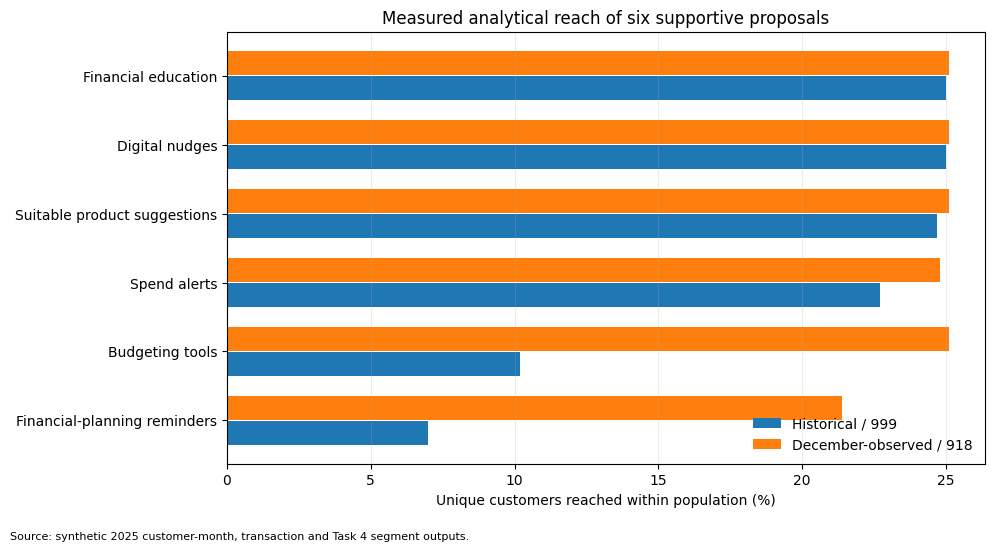

Saved: /home/pearspringmind/Studying/BI-UEL/image/task5/task5_action_reach.png


In [13]:
reach_for_chart = historical_reach_table[["action", "historical_reach_pct"]].merge(
    december_reach_table[["action", "december_reach_pct"]], on="action", validate="one_to_one"
).sort_values("historical_reach_pct")
chart_positions = np.arange(len(reach_for_chart))
figure, axis = plt.subplots(figsize=(10, 5.5))
axis.barh(chart_positions - 0.18, reach_for_chart["historical_reach_pct"], height=0.34, label="Historical / 999")
axis.barh(chart_positions + 0.18, reach_for_chart["december_reach_pct"], height=0.34, label="December-observed / 918")
axis.set_yticks(chart_positions, reach_for_chart["action"])
axis.set_xlabel("Unique customers reached within population (%)")
axis.set_title("Measured analytical reach of six supportive proposals")
axis.legend(frameon=False)
axis.grid(axis="x", alpha=0.25)
figure.text(0.01, 0.01, "Source: synthetic 2025 customer-month, transaction and Task 4 segment outputs.", fontsize=8)
figure.tight_layout(rect=(0, 0.04, 1, 1))
reach_chart_path = TASK5_IMAGE_DIR / "task5_action_reach.png"
figure.savefig(reach_chart_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close(figure)
print(f"Saved: {reach_chart_path}")

**Interpretation.** The paired bars compare unique-customer reach using the correct denominator for each population. Differences reflect distinct historical versus December predicates and observation windows—not customer loss, current contactability, or expected intervention impact. Reach alone does not determine priority; the evidence ranking and caveats below must be considered with it.

## 7. Overlap and union by population

The union is computed from distinct IDs. Pairwise intersections show why summing six action counts would overstate reach.

In [14]:
def summarize_overlap(targets, denominator, population_name):
    target_matrix = pd.DataFrame(targets).astype(bool)
    actions_per_customer = target_matrix.sum(axis=1)
    overlap_summary = {
        "population": population_name,
        "denominator": denominator,
        "union_unique_customers": int(actions_per_customer.gt(0).sum()),
        "union_pct": round(100 * actions_per_customer.gt(0).sum() / denominator, 1),
        "customers_in_2plus_actions": int(actions_per_customer.ge(2).sum()),
        "customers_in_2plus_actions_pct": round(100 * actions_per_customer.ge(2).sum() / denominator, 1),
        "maximum_actions_for_one_customer": int(actions_per_customer.max()),
    }
    pairwise = pd.DataFrame(0, index=target_matrix.columns, columns=target_matrix.columns, dtype="int64")
    for left_action, right_action in combinations(target_matrix.columns, 2):
        intersection_count = int((target_matrix[left_action] & target_matrix[right_action]).sum())
        pairwise.loc[left_action, right_action] = intersection_count
        pairwise.loc[right_action, left_action] = intersection_count
    for action_name in target_matrix.columns:
        pairwise.loc[action_name, action_name] = int(target_matrix[action_name].sum())
    if overlap_summary["union_unique_customers"] > denominator:
        raise AssertionError("Distinct-customer union cannot exceed its population.")
    return overlap_summary, pairwise

historical_overlap_summary, historical_pairwise_overlap = summarize_overlap(
    historical_targets, 999, "Historical/model-assigned"
)
december_overlap_summary, december_pairwise_overlap = summarize_overlap(
    december_targets, 918, "Observed in December 2025"
)
display(pd.DataFrame([historical_overlap_summary, december_overlap_summary]))
print("Historical pairwise intersection counts (diagonal = action reach)")
display(historical_pairwise_overlap)
print("December-observed pairwise intersection counts (diagonal = action reach)")
display(december_pairwise_overlap)

,population,denominator,union_unique_customers,union_pct,customers_in_2plus_actions,customers_in_2plus_actions_pct,maximum_actions_for_one_customer
0,Historical/model-assigned,999,757,75.8,292,29.2,5
1,Observed in December 2025,918,686,74.7,348,37.9,5


Historical pairwise intersection counts (diagonal = action reach)


,Budgeting tools,Spend alerts,Financial-planning reminders,Financial education,Digital nudges,Suitable product suggestions
Budgeting tools,102,29,25,21,19,32
Spend alerts,29,227,47,30,67,87
Financial-planning reminders,25,47,70,13,24,23
Financial education,21,30,13,250,49,0
Digital nudges,19,67,24,49,250,42
Suitable product suggestions,32,87,23,0,42,247


December-observed pairwise intersection counts (diagonal = action reach)


,Budgeting tools,Spend alerts,Financial-planning reminders,Financial education,Digital nudges,Suitable product suggestions
Budgeting tools,230,137,196,99,56,29
Spend alerts,137,228,137,104,62,16
Financial-planning reminders,196,137,196,89,52,21
Financial education,99,104,89,230,49,0
Digital nudges,56,62,52,49,230,69
Suitable product suggestions,29,16,21,0,69,230


## 8. Transparent priority order

Three ranks remain separate: held-out temporal replication, full-year historical reach and December-observed reach. Pilot order uses the out-of-time replication rank first, historical reach second and action name as a deterministic tie-break. The Jan–Aug targets and Sep–Dec outcomes are disjoint observational windows; this order is a testing priority, not evidence of causal efficacy or expected uplift.

In [15]:
action_summary = historical_reach_table.drop(columns=["target_predicate"]).merge(
    december_reach_table.drop(columns=["target_predicate"]), on="action", validate="one_to_one"
).merge(evidence_table, on="action", validate="one_to_one")
priority_order = action_summary.sort_values(
    ["evidence_rank", "historical_reach_rank", "action"], ascending=[True, True, True]
).reset_index(drop=True)
priority_order["priority_rank"] = np.arange(1, len(priority_order) + 1)
action_summary = action_summary.merge(
    priority_order[["action", "priority_rank"]], on="action", validate="one_to_one"
)
display(priority_order[[
    "priority_rank", "action", "evidence_rank", "historical_reach_rank",
    "december_reach_rank", "historical_reach_n", "historical_reach_pct",
    "december_reach_n", "december_reach_pct", "training_target_customers",
    "holdout_target_customers", "holdout_other_customers",
    "holdout_standardized_contrast",
]].round(3))
def proposal_detail(action_name):
    result = action_summary.loc[action_summary["action"].eq(action_name)].iloc[0]
    specification = action_specs[action_name]
    evidence_statement = (
        f"{result['validation_outcome']}: Jan–Aug target customers (n={int(result['holdout_target_customers'])}) "
        f"mean {result['holdout_target_mean']:.3f} versus "
        f"{result['holdout_other_mean']:.3f} for other validation-eligible customers "
        f"(n={int(result['holdout_other_customers'])}); direction-aligned holdout contrast "
        f"{result['holdout_standardized_contrast']:.2f} population SD."
    )
    cluster_statement = (
        f"{result['anchor_cluster_label']} (cluster {result['anchor_cluster']}): "
        f"{result['anchor_cluster_target_pct']:.1f}% targeted within cluster versus "
        f"{result['other_clusters_target_pct']:.1f}% across other clusters. "
        f"Profile: {result['anchor_cluster_profile']}"
    )
    return pd.DataFrame({
        "Metric": [
            "Out-of-time descriptive replication", "Cluster link and cross-cluster need",
            "Historical target predicate", "Historical reach",
            "December target predicate", "December-observed reach",
            "Observation caveat", "Supportive action", "Future KPI",
            "Replication / historical reach / pilot priority ranks",
        ],
        "Value": [
            evidence_statement, cluster_statement, specification["historical_predicate"],
            f"{int(result['historical_reach_n'])} / 999 ({result['historical_reach_pct']:.1f}%)",
            specification["december_predicate"],
            f"{int(result['december_reach_n'])} / 918 ({result['december_reach_pct']:.1f}%)",
            specification["caveat"], specification["action"], specification["future_kpi"],
            f"{int(result['evidence_rank'])} / {int(result['historical_reach_rank'])} / {int(result['priority_rank'])}",
        ],
    })

,priority_rank,action,evidence_rank,historical_reach_rank,december_reach_rank,historical_reach_n,historical_reach_pct,december_reach_n,december_reach_pct,training_target_customers,holdout_target_customers,holdout_other_customers,holdout_standardized_contrast
0,1,Financial education,1,2,3,250,25.0,230,25.1,227,227,681,1.292
1,2,Financial-planning reminders,2,6,6,70,7.0,196,21.4,52,52,856,1.277
2,3,Digital nudges,3,1,2,250,25.0,230,25.1,227,227,681,0.997
3,4,Budgeting tools,4,5,1,102,10.2,230,25.1,183,183,725,0.813
4,5,Suitable product suggestions,5,3,4,247,24.7,230,25.1,227,227,681,0.611
5,6,Spend alerts,6,4,5,227,22.7,228,24.8,227,227,681,0.413


## Proposal 1 — Budgeting tools

In [16]:
display(proposal_detail("Budgeting tools"))

,Metric,Value
0,Out-of-time descriptive replication,Sep–Dec share above Jan–Aug spend/income q75: ...
1,Cluster link and cross-cluster need,Higher online-spend share — Segment 2 (cluster...
2,Historical target predicate,At least 3 observed months and spend/income >=...
3,Historical reach,102 / 999 (10.2%)
4,December target predicate,December spend/income >= its observed-customer...
5,December-observed reach,230 / 918 (25.1%)
6,Observation caveat,Historical persistence requires 3+ months; a D...
7,Supportive action,Offer an opt-in budget planner with category l...
8,Future KPI,Randomized pilot: budget set-up rate and 3-mon...
9,Replication / historical reach / pilot priorit...,4 / 5 / 4


## Proposal 2 — Spend alerts

In [17]:
display(proposal_detail("Spend alerts"))

,Metric,Value
0,Out-of-time descriptive replication,Sep–Dec peak spend / Jan–Aug personal median: ...
1,Cluster link and cross-cluster need,Lower-frequency activity — Segment 1 (cluster ...
2,Historical target predicate,At least 3 observed months and peak/monthly-pe...
3,Historical reach,227 / 999 (22.7%)
4,December target predicate,December/prior-personal-median spend >= 2.203;...
5,December-observed reach,228 / 918 (24.8%)
6,Observation caveat,December is compared with each customer's avai...
7,Supportive action,"Let customers opt into real-time, user-set spe..."
8,Future KPI,Randomized pilot: alert set-up/acknowledgement...
9,Replication / historical reach / pilot priorit...,6 / 4 / 6


## Proposal 3 — Financial-planning reminders

In [18]:
display(proposal_detail("Financial-planning reminders"))

,Metric,Value
0,Out-of-time descriptive replication,Sep–Dec share of months with health score < 40...
1,Cluster link and cross-cluster need,Lower-frequency activity — Segment 1 (cluster ...
2,Historical target predicate,At least one observed month with financial_hea...
3,Historical reach,70 / 999 (7.0%)
4,December target predicate,"December health < 40, or high spend/income (>=..."
5,December-observed reach,196 / 918 (21.4%)
6,Observation caveat,The wellbeing score supports assistance only; ...
7,Supportive action,Offer neutral calendar reminders for bill revi...
8,Future KPI,"Randomized pilot: reminder completion, plannin..."
9,Replication / historical reach / pilot priorit...,2 / 6 / 2


## Proposal 4 — Financial education

In [19]:
display(proposal_detail("Financial education"))

,Metric,Value
0,Out-of-time descriptive replication,Sep–Dec median discretionary-spend share: Jan–...
1,Cluster link and cross-cluster need,Higher online-spend share — Segment 2 (cluster...
2,Historical target predicate,Median discretionary-spend share >= historical...
3,Historical reach,250 / 999 (25.0%)
4,December target predicate,December discretionary-spend share >= observed...
5,December-observed reach,230 / 918 (25.1%)
6,Observation caveat,"A high discretionary share is descriptive, not..."
7,Supportive action,"Offer optional, non-judgmental modules on need..."
8,Future KPI,"Randomized pilot: module completion, knowledge..."
9,Replication / historical reach / pilot priorit...,1 / 2 / 1


## Proposal 5 — Digital nudges

In [20]:
display(proposal_detail("Digital nudges"))

,Metric,Value
0,Out-of-time descriptive replication,Sep–Dec non-POS transaction share: Jan–Aug tar...
1,Cluster link and cross-cluster need,Lower-frequency activity — Segment 1 (cluster ...
2,Historical target predicate,Full-year non-POS transaction share <= lower q...
3,Historical reach,250 / 999 (25.0%)
4,December target predicate,December non-POS transaction share <= observed...
5,December-observed reach,230 / 918 (25.1%)
6,Observation caveat,QR is counted as digital/non-POS. Lower use ca...
7,Supportive action,Provide an optional QR/mobile/e-commerce featu...
8,Future KPI,Randomized pilot: consented feature-tour compl...
9,Replication / historical reach / pilot priorit...,3 / 1 / 3


## Proposal 6 — Suitable product suggestions

**Suitability and consent gate:** the behavioral predicate is not product eligibility. A suggestion may be shown only after separate affordability, product-suitability, privacy, fairness, contact-permission and informed-consent checks. No credit approval, denial, limit reduction or account blocking may use `financial_health_score` or these proposal predicates.

In [21]:
display(proposal_detail("Suitable product suggestions"))

,Metric,Value
0,Out-of-time descriptive replication,Sep–Dec median essential-spend share: Jan–Aug ...
1,Cluster link and cross-cluster need,Lower-frequency activity — Segment 1 (cluster ...
2,Historical target predicate,At least 3 observed months and median essentia...
3,Historical reach,247 / 999 (24.7%)
4,December target predicate,December essential-spend share >= observed-cus...
5,December-observed reach,230 / 918 (25.1%)
6,Observation caveat,Behavior is only a conversation signal. Produc...
7,Supportive action,"Only after separate suitability, affordability..."
8,Future KPI,Controlled pilot: suitability-pass and informe...
9,Replication / historical reach / pilot priorit...,5 / 3 / 5


## 9. Compact action plan

In [22]:
compact_action_plan = action_summary.copy()
compact_action_plan["finding"] = compact_action_plan.apply(
    lambda row: (
        f"{row['validation_outcome']}: training-target n={int(row['holdout_target_customers'])}, "
        f"other n={int(row['holdout_other_customers'])}; means "
        f"{row['holdout_target_mean']:.3f} vs {row['holdout_other_mean']:.3f}; "
        f"aligned contrast {row['holdout_standardized_contrast']:.2f} SD"
    ),
    axis=1,
)
compact_action_plan["cluster_link"] = compact_action_plan.apply(
    lambda row: (
        f"{row['anchor_cluster_label']}: {row['anchor_cluster_target_pct']:.1f}% within cluster vs "
        f"{row['other_clusters_target_pct']:.1f}% elsewhere"
    ),
    axis=1,
)
compact_action_plan["historical_reach"] = compact_action_plan.apply(
    lambda row: f"{int(row['historical_reach_n'])}/999 ({row['historical_reach_pct']:.1f}%)", axis=1
)
compact_action_plan["december_reach"] = compact_action_plan.apply(
    lambda row: f"{int(row['december_reach_n'])}/918 ({row['december_reach_pct']:.1f}%)", axis=1
)
compact_action_plan["supportive_action"] = compact_action_plan["action"].map(
    {action: details["action"] for action, details in action_specs.items()}
)
compact_action_plan["future_kpi"] = compact_action_plan["action"].map(
    {action: details["future_kpi"] for action, details in action_specs.items()}
)
display(compact_action_plan.sort_values("priority_rank")[[
    "priority_rank", "action", "finding", "cluster_link",
    "historical_reach", "december_reach", "supportive_action", "future_kpi",
]])

,priority_rank,action,finding,cluster_link,historical_reach,december_reach,supportive_action,future_kpi
1,1,Financial education,Sep–Dec median discretionary-spend share: trai...,Higher online-spend share — Segment 2: 50.9% w...,250/999 (25.0%),230/918 (25.1%),"Offer optional, non-judgmental modules on need...","Randomized pilot: module completion, knowledge..."
5,2,Financial-planning reminders,Sep–Dec share of months with health score < 40...,Lower-frequency activity — Segment 1: 8.8% wit...,70/999 (7.0%),196/918 (21.4%),Offer neutral calendar reminders for bill revi...,"Randomized pilot: reminder completion, plannin..."
0,3,Digital nudges,Sep–Dec non-POS transaction share: training-ta...,Lower-frequency activity — Segment 1: 36.5% wi...,250/999 (25.0%),230/918 (25.1%),Provide an optional QR/mobile/e-commerce featu...,Randomized pilot: consented feature-tour compl...
4,4,Budgeting tools,Sep–Dec share above Jan–Aug spend/income q75: ...,Higher online-spend share — Segment 2: 11.7% w...,102/999 (10.2%),230/918 (25.1%),Offer an opt-in budget planner with category l...,Randomized pilot: budget set-up rate and 3-mon...
2,5,Suitable product suggestions,Sep–Dec median essential-spend share: training...,Lower-frequency activity — Segment 1: 40.9% wi...,247/999 (24.7%),230/918 (25.1%),"Only after separate suitability, affordability...",Controlled pilot: suitability-pass and informe...
3,6,Spend alerts,Sep–Dec peak spend / Jan–Aug personal median: ...,Lower-frequency activity — Segment 1: 32.5% wi...,227/999 (22.7%),228/918 (24.8%),"Let customers opt into real-time, user-set spe...",Randomized pilot: alert set-up/acknowledgement...


## 10. Limits and responsible use

- The data are synthetic. Absolute VND values are not realistic; ratio and within-customer comparisons are used for targeting.
- All findings are descriptive associations. Jan–Aug targets and Sep–Dec outcomes provide an out-of-time repeatability check, not causal intervention efficacy; no uplift, retention or wellbeing improvement is claimed before a controlled evaluation.
- The 999-person population is historical/model-assigned. The 918-person December subset is recently observed only. Neither establishes current retention, churn, contactability, channel permission or consent.
- December is an observed-month snapshot. Spend alerts use an available prior-month baseline, and customers without prior history receive no trend label. Other one-month profiles are explicitly provisional.
- Cluster anchors describe where a measured need is most prevalent; cluster membership alone is never sufficient. Small clusters and weakly separated clusters should be interpreted cautiously.
- Product suggestions require a separate suitability, affordability, privacy, fairness and informed-consent gate. Suppress any unsuitable or unwanted suggestion.
- `financial_health_score` remains a wellbeing indicator only and must never be used to approve or deny credit, cut a limit, or block an account.